# OTF Scan Plan

Plan a simple raster scan in galactic coordinates.
Check alt/az limits at the planned observation time and visualize coverage.

In [1]:
import sys; sys.path.insert(0, '..')
import ugradiolab.plotting as plotting  # applies rcParams
from plotters import plot_scan_pattern, plot_altaz_mollweide, plot_timeline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
import astropy.coordinates as ac
from astropy.time import Time, TimeDelta

%matplotlib inline

# Leuschner Observatory
LEO_LAT, LEO_LON, LEO_ALT = 37.9183, -122.1067, 304.0
location = ac.EarthLocation(lat=LEO_LAT * u.deg, lon=LEO_LON * u.deg,
                            height=LEO_ALT * u.m)

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 0. Project footprints (Mollweide)

All candidate survey regions overlaid on a galactic Mollweide projection.

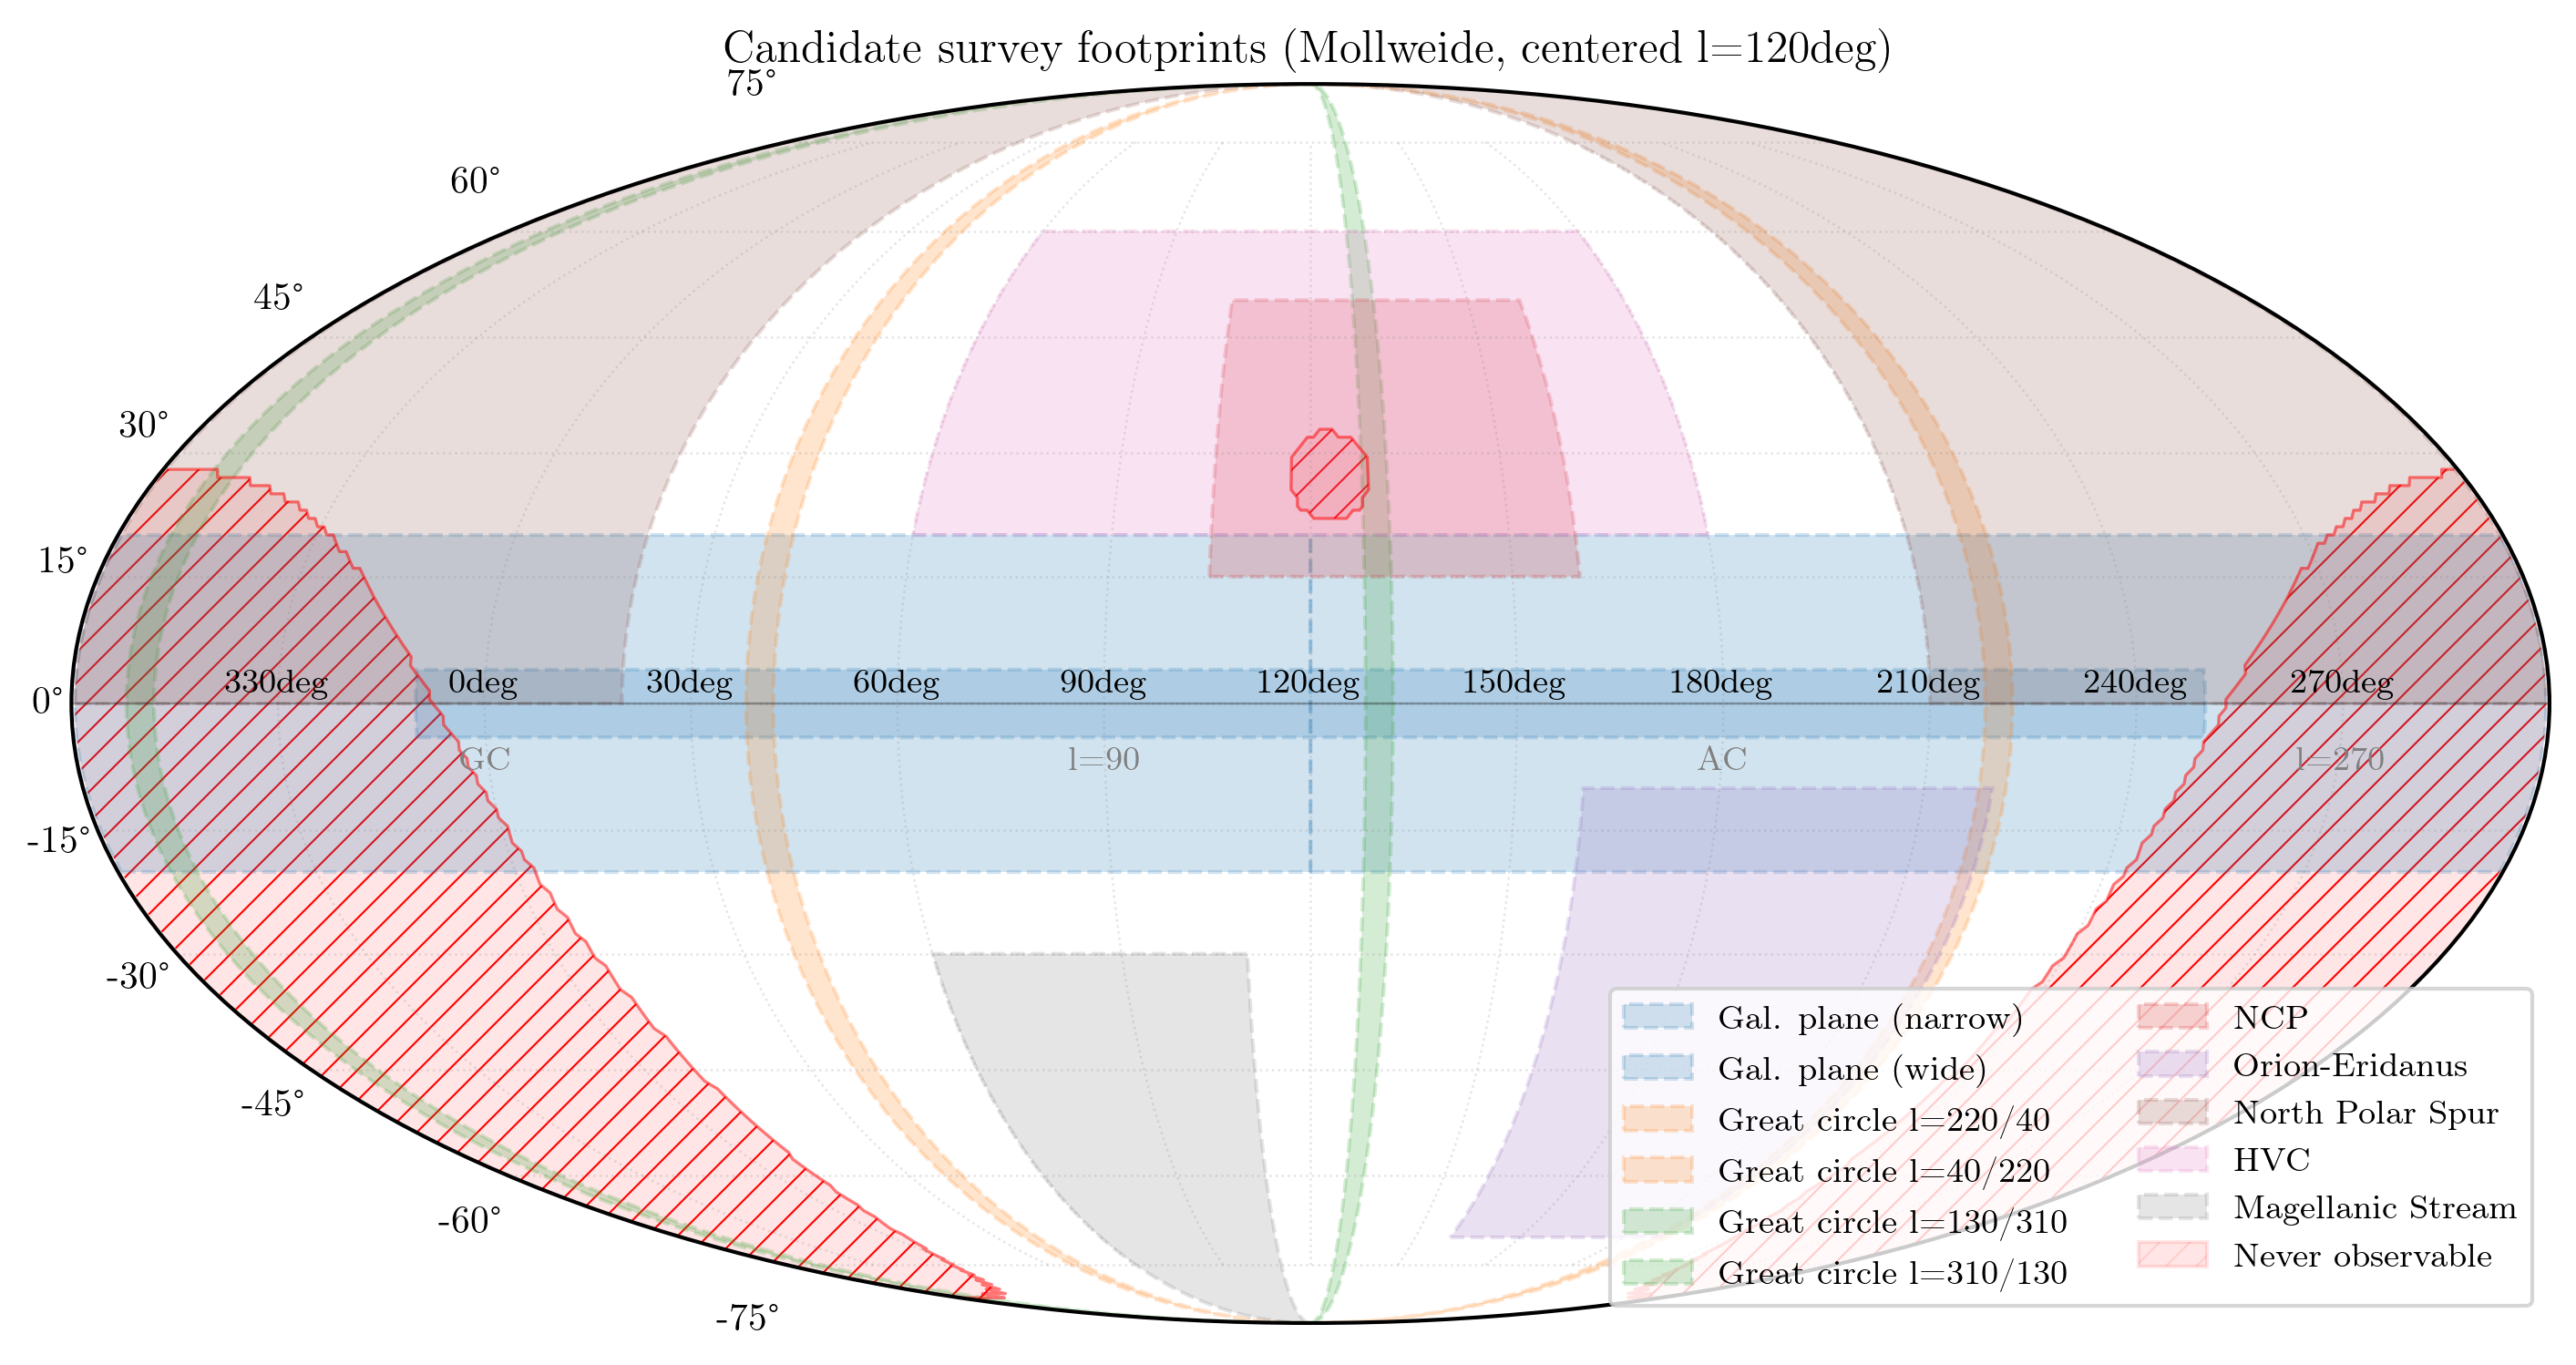

Never-observable sky: 11893/64800 grid points (18%)

Project                        l range        b range        Area (deg^2) Cells (2deg)
--------------------------------------------------------------------------------
Gal. plane (narrow)            [-10,250]     [ -4, +4]         2080        520
Gal. plane (wide)              [  0,360]     [-20,+20]        14400       3600
Great circle l=220/40          [218,222]     [-90,+90]          720        180
Great circle l=130/310         [128,132]     [-90,+90]          720        180
NCP                            [105,160]     [+15,+50]         1624        459
Orion-Eridanus                 [160,220]     [-70,-10]         2758        900
North Polar Spur               [210, 20]     [ +0,+90]        10819       3825
HVC                            [ 60,180]     [+20,+60]         3677       1200
Magellanic Stream              [ 60,110]     [-90,-30]         1500        750


In [2]:
from matplotlib.patches import Polygon, Rectangle
from matplotlib.collections import PatchCollection

MOLL_CENTER = 120.0
MOLL_SEAM = (MOLL_CENTER + 180) % 360  # l=300 is the seam
MIN_ALT_DEG = 17.0
MAX_ALT_DEG = 83.0
AZ_MIN_DEG, AZ_MAX_DEG = 7.0, 348.0

# --- Define candidate survey footprints ---
projects_raw = [
    ('Gal. plane (narrow)',     -10, 250,   -4,   4, 'C0'),
    ('Gal. plane (wide)',         0, 360,  -20,  20, 'C0'),
    ('Great circle l=220/40',   218, 222,  -90,  90, 'C1'),
    ('Great circle l=40/220',    38,  42,  -90,  90, 'C1'),
    ('Great circle l=130/310',  128, 132,  -90,  90, 'C2'),
    ('Great circle l=310/130',  308, 312,  -90,  90, 'C2'),
    ('NCP',                     105, 160,   15,  50, 'C3'),
    ('Orion-Eridanus',          160, 220,  -70, -10, 'C4'),
    ('North Polar Spur',        210, 380,    0,  90, 'C5'),
    ('HVC',                      60, 180,   20,  60, 'C6'),
    ('Magellanic Stream',        60, 110,  -90, -30, 'C7'),
]

def normalize_l(l):
    return l % 360

def crosses_seam(l_min, l_max):
    span = l_max - l_min
    if span >= 360:
        return True
    lmin_n = normalize_l(l_min)
    lmax_n = normalize_l(l_max)
    if lmin_n <= lmax_n:
        return lmin_n < MOLL_SEAM < lmax_n
    else:
        return MOLL_SEAM > lmin_n or MOLL_SEAM < lmax_n

projects = []
for name, l_min, l_max, b_min, b_max, color in projects_raw:
    if l_max - l_min >= 360:
        projects.append((name, MOLL_SEAM + 0.5, MOLL_SEAM + 180, b_min, b_max, color))
        projects.append((name, MOLL_SEAM + 180, MOLL_SEAM + 359.5, b_min, b_max, color))
    elif crosses_seam(l_min, l_max):
        projects.append((name, l_min, MOLL_SEAM - 0.5, b_min, b_max, color))
        projects.append((name, MOLL_SEAM + 0.5, l_max, b_min, b_max, color))
    else:
        projects.append((name, l_min, l_max, b_min, b_max, color))

def wrap_l(l):
    l = l - MOLL_CENTER
    if l > 180: l -= 360
    if l < -180: l += 360
    return l

def make_rect_patch(l_min, l_max, b_min, b_max):
    n = 50
    wl_min, wl_max = wrap_l(l_min), wrap_l(l_max)
    if wl_min > wl_max:
        return None
    l_bot = np.linspace(wl_min, wl_max, n)
    l_top = np.linspace(wl_max, wl_min, n)
    b_left = np.linspace(b_min, b_max, n)
    b_right = np.linspace(b_max, b_min, n)
    ls = np.concatenate([l_bot, np.full(n, wl_max), l_top, np.full(n, wl_min)])
    bs = np.concatenate([np.full(n, b_min), b_left, np.full(n, b_max), b_right])
    return np.column_stack([np.deg2rad(ls), np.deg2rad(bs)])

# --- Compute never-observable mask on a dense grid ---
l_dense = np.arange(-179.5, 180.5, 1.0)
b_dense = np.arange(-89.5, 90.5, 1.0)
L_dense, B_dense = np.meshgrid(l_dense, b_dense)

L_true = (L_dense + MOLL_CENTER) % 360

gc_grid = ac.SkyCoord(l=L_true.ravel() * u.deg, b=B_dense.ravel() * u.deg,
                      frame='galactic')
dec_rad = np.deg2rad(gc_grid.transform_to(ac.ICRS()).dec.deg).reshape(L_dense.shape)
lat_rad = np.deg2rad(LEO_LAT)

ha_steps = np.deg2rad(np.arange(0, 360, 1))
alt_lo = np.deg2rad(MIN_ALT_DEG)
alt_hi = np.deg2rad(MAX_ALT_DEG)
az_lo = np.deg2rad(AZ_MIN_DEG)
az_hi = np.deg2rad(AZ_MAX_DEG)

observable = np.zeros(L_dense.shape, dtype=bool)

for ha in ha_steps:
    sin_alt = (np.sin(lat_rad) * np.sin(dec_rad)
               + np.cos(lat_rad) * np.cos(dec_rad) * np.cos(ha))
    alt = np.arcsin(np.clip(sin_alt, -1, 1))

    cos_az_num = (np.sin(dec_rad) - np.sin(lat_rad) * sin_alt)
    cos_az_den = np.cos(lat_rad) * np.cos(alt)
    with np.errstate(invalid='ignore', divide='ignore'):
        cos_az = np.clip(cos_az_num / cos_az_den, -1, 1)
    az = np.arccos(cos_az)
    az = np.where(np.sin(ha) > 0, 2 * np.pi - az, az)

    alt_ok = (alt >= alt_lo) & (alt <= alt_hi)
    az_ok = (az >= az_lo) & (az <= az_hi)
    observable |= (alt_ok & az_ok)

inacc_mask = (~observable).astype(float)

fig, _ax = plotting.landscapewidth_figure(5)
_ax.remove()
ax = fig.add_subplot(111, projection='mollweide')
ax.grid(True, alpha=plotting.ALPHA_EXTRA_LIGHT)

# Galactic plane
l_line = np.linspace(-np.pi, np.pi, 500)
ax.plot(l_line, np.zeros_like(l_line), 'k-', lw=plotting.LW_FINE, alpha=0.3)

# --- Inaccessible region: red hatched contour ---
import matplotlib as mpl
mpl.rcParams['hatch.color'] = 'red'
mpl.rcParams['hatch.linewidth'] = 0.5

cs = ax.contourf(np.deg2rad(L_dense), np.deg2rad(B_dense), inacc_mask,
                 levels=[0.5, 1.5], colors=['red'], alpha=0.1,
                 hatches=['///'], zorder=1)

ax.contour(np.deg2rad(L_dense), np.deg2rad(B_dense), inacc_mask,
           levels=[0.5], colors=['red'], linewidths=0.8, alpha=0.5, zorder=2)

mpl.rcParams['hatch.color'] = 'black'

legend_proxy = Rectangle((0, 0), 1, 1, facecolor='red', alpha=0.1,
                          edgecolor='red', hatch='///', label='Never observable')

plotted_labels = set()
for name, l_min, l_max, b_min, b_max, color in projects:
    verts = make_rect_patch(l_min, l_max, b_min, b_max)
    if verts is not None:
        label = name if name not in plotted_labels else None
        poly = plt.Polygon(verts, alpha=plotting.ALPHA_EXTRA_LIGHT, facecolor=color, edgecolor=color,
                          lw=plotting.LW_LIGHT, linestyle='--', label=label)
        ax.add_patch(poly)
        if label:
            plotted_labels.add(name)

tick_locs = np.arange(-150, 180, 30)
tick_labels = [f'{int((t + MOLL_CENTER) % 360)}deg' for t in tick_locs]
ax.set_xticks(np.deg2rad(tick_locs))
ax.set_xticklabels(tick_labels, fontsize=plotting.LEGEND_SIZE)

for ld, name in [(0, 'GC'), (90, 'l=90'), (180, 'AC'), (270, 'l=270')]:
    lp = wrap_l(ld)
    if -180 <= lp <= 180:
        ax.annotate(name, (np.deg2rad(lp), np.deg2rad(-5)),
                    fontsize=plotting.LEGEND_SIZE, ha='center', va='top', color='gray')

ax.set_title(f'Candidate survey footprints (Mollweide, centered l={MOLL_CENTER:.0f}deg)',
             fontsize=plotting.EMPHASIS_SIZE)

handles, labels = ax.get_legend_handles_labels()
handles.append(legend_proxy)
labels.append('Never observable')
ax.legend(handles, labels, fontsize=plotting.LEGEND_SIZE, loc='lower right', ncol=2)

fig.tight_layout()
plt.show()

n_inacc = int(inacc_mask.sum())
n_total = inacc_mask.size
print(f'Never-observable sky: {n_inacc}/{n_total} grid points '
      f'({100*n_inacc/n_total:.0f}%)')

# Summary table
summary_projects = [
    ('Gal. plane (narrow)',     -10, 250,   -4,   4),
    ('Gal. plane (wide)',         0, 360,  -20,  20),
    ('Great circle l=220/40',   218, 222,  -90,  90),
    ('Great circle l=130/310',  128, 132,  -90,  90),
    ('NCP',                     105, 160,   15,  50),
    ('Orion-Eridanus',          160, 220,  -70, -10),
    ('North Polar Spur',        210, 380,    0,  90),
    ('HVC',                      60, 180,   20,  60),
    ('Magellanic Stream',        60, 110,  -90, -30),
]
print(f'\n{"Project":<30} {"l range":<14} {"b range":<14} {"Area (deg^2)":>10} {"Cells (2deg)":>10}')
print('-' * 80)
for name, l_min, l_max, b_min, b_max in summary_projects:
    dl = l_max - l_min
    db = b_max - b_min
    b_mid = (b_max + b_min) / 2
    area = dl * db * np.cos(np.deg2rad(b_mid))
    n_cells = int(dl / 2) * int(db / 2)
    l_max_disp = l_max if l_max <= 360 else l_max - 360
    print(f'{name:<30} [{l_min:>3},{l_max_disp:>3}]     [{b_min:>+3},{b_max:>+3}]     {area:>8.0f}   {n_cells:>8}')

## 1. Scan configuration

In [3]:
from manifest import read_manifest, pairs_target
from pathlib import Path

# =====================================================================
# DR8a: Fill all incomplete even-grid plane cells (|b| <= 4)
# DR8b: New interleaved grid — odd l (13,15,...249), b = -3,-1,+1,+3
#
# 2026-04-21 ~19:17 UTC  (2026-04-21 ~12:17 PDT)
#
# Part 1 (DR8a fills, setting): l=76,98,112,117 setting now; inner
#         galaxy (l<60) and l=174,224,252 retried when they rise.
# Part 2 (DR8b odd grid, rising): l=129-197 odd accessible now (5.3h);
#         remainder (l=13-127, l=199-249) in future sessions.
# =====================================================================

SURVEY_PARTS = [
    {   # Part 1 (DR8a): Fill all incomplete even-grid plane cells
        'name': 'Plane fills — even grid (DR8a)',
        'l_min': 12, 'l_max': 260,
        'b_min': -4, 'b_max': 4,
        'step': 2,
        'dumps_per_band': 4,
        'parallelogram': False,
        'fills_only': True,   # observe script: keeps only manifest-incomplete cells
    },
    {   # Part 2 (DR8b): Interleaved odd-l / odd-b grid, rising side
        # l=13,15,...,197 accessible tonight; full range l=13-249 over multiple sessions
        'name': 'Odd-grid plane — rising (DR8b)',
        'l_min': 129, 'l_max': 197,
        'b_min': -3, 'b_max': 3,
        'step': 2,   # l_min=129 (odd) + step=2 → 129,131,...,197; b: -3,-1,+1,+3
        'dumps_per_band': 4,
        'parallelogram': False,
    },
]

# --- Constraints ---
HPBW_DEG       = 3.4
MIN_ALT_DEG    = 17.0
MAX_ALT_DEG    = 83.0
AZ_MIN, AZ_MAX = 7.0, 348.0
SIDE           = 'auto'

# --- Timing ---
DUMP_CADENCE_S = 17.0       # measured pipelined cadence
SLEW_TIME_S    = 5.0
T_START        = Time.now()

# --- Manifest ---
MANIFEST_PATH  = Path('../survey_manifest.json')

# =====================================================================
# Load manifest
# =====================================================================

manifest = read_manifest(MANIFEST_PATH)
if manifest:
    n_complete = sum(1 for v in manifest.values() if v.get('complete'))
    n_incomplete = sum(1 for v in manifest.values() if not v.get('complete'))
    print(f'Manifest loaded: {len(manifest)} pointings ({n_complete} complete, {n_incomplete} incomplete)')
else:
    print(f'No manifest found at {MANIFEST_PATH} --- all cells treated as incomplete')

# =====================================================================
# Summary
# =====================================================================

print(f'\nStart: {T_START.iso} UTC')
print(f'Cadence: {DUMP_CADENCE_S:.0f}s/dump (measured)')
print(f'Side: {SIDE}')
print()

for part in SURVEY_PARTS:
    n_l = len(range(part['l_min'], part['l_max'] + 1, part['step']))
    n_b = len(range(part['b_min'], part['b_max'] + 1, part['step']))
    n = n_l * n_b
    dpc = part['dumps_per_band'] * 2
    cell_time = dpc * DUMP_CADENCE_S + SLEW_TIME_S

    if part.get('fills_only'):
        # Count manifest-incomplete cells in region
        n_manifest_complete = 0
        n_fills = 0
        for l in range(part['l_min'], part['l_max'] + 1, part['step']):
            for b in range(part['b_min'], part['b_max'] + 1, part['step']):
                info = manifest.get((l % 360, b))
                if info:
                    if info.get('complete'):
                        n_manifest_complete += 1
                    else:
                        n_fills += 1
        n_remaining = n_fills
        label = f'{n_fills} incomplete (fills only)'
    else:
        n_manifest_complete = 0
        for l in range(part['l_min'], part['l_max'] + 1, part['step']):
            for b in range(part['b_min'], part['b_max'] + 1, part['step']):
                info = manifest.get((l % 360, b))
                if info and info.get('complete'):
                    n_manifest_complete += 1
        n_remaining = n - n_manifest_complete
        label = f'{n_remaining} remaining'

    t_h = n_remaining * cell_time / 3600

    print(f'{part["name"]}:')
    print(f'  l=[{part["l_min"]}, {part["l_max"]}], b=[{part["b_min"]}, {part["b_max"]}], step={part["step"]}')
    print(f'  Grid: {n} total')
    print(f'  {label}')
    print(f'  {dpc} dumps/cell x {DUMP_CADENCE_S:.0f}s = {cell_time:.0f}s/cell')
    print(f'  Estimated: {t_h:.1f}h')
    print()

Manifest loaded: 1174 pointings (1149 complete, 25 incomplete)

Start: 2026-04-21 21:11:34.871 UTC
Cadence: 17s/dump (measured)
Side: auto

Plane fills — even grid (DR8a):
  l=[12, 260], b=[-4, 4], step=2
  Grid: 625 total
  11 incomplete (fills only)
  8 dumps/cell x 17s = 141s/cell
  Estimated: 0.4h

Odd-grid plane — rising (DR8b):
  l=[129, 197], b=[-3, 3], step=2
  Grid: 140 total
  140 remaining
  8 dumps/cell x 17s = 141s/cell
  Estimated: 5.5h



## 2. Build grid and check visibility

In [4]:
# =====================================================================
# Build grid with all constraints:
#   1. No crossing of forbidden azimuth (348deg-7deg)
#   2. Forbidden altitude (< 17deg or > 83deg)
#   3. Rising-only or setting-only survey
#   4. Parallelogram (iso-HA slant) or simple raster
#   5. Cells requiring extra data (manifest: incomplete)
#   6. Completed cells (manifest: skip)
# =====================================================================

def compute_iso_ha_slant(l_center, b_center, obs_time):
    """Compute iso-HA slant at (l_center, b_center): deg l per deg b."""
    def _ha(l, b):
        gc = ac.SkyCoord(l=l * u.deg, b=b * u.deg, frame='galactic')
        icrs = gc.transform_to(ac.ICRS())
        lst = obs_time.sidereal_time('apparent', longitude=LEO_LON * u.deg)
        return (lst - icrs.ra).wrap_at(12 * u.hourangle).deg
    dha_dl = (_ha(l_center + 1, b_center) - _ha(l_center - 1, b_center)) / 2
    dha_db = (_ha(l_center, b_center + 1) - _ha(l_center, b_center - 1)) / 2
    return -dha_db / dha_dl

sim = []
t_current = T_START
total_cells = 0
total_time_s = 0

for part in SURVEY_PARTS:
    l_min, l_max = part['l_min'], part['l_max']
    b_min, b_max = part['b_min'], part['b_max']
    step = part['step']
    dpc = part['dumps_per_band'] * 2
    cell_dwell = dpc * DUMP_CADENCE_S
    cell_time = cell_dwell + SLEW_TIME_S
    use_parallelogram = part.get('parallelogram', False)

    # --- Step 1: Build candidate grid (raster or parallelogram) ---
    b_vals = list(range(b_min, b_max + 1, step))
    l_center = (l_min + l_max) / 2
    b_center = (b_min + b_max) / 2

    if use_parallelogram:
        slant = compute_iso_ha_slant(l_center, b_center, T_START)
        print(f'{part["name"]}: parallelogram slant = {slant:.2f} deg l / deg b')
    else:
        slant = 0.0

    all_cells = []
    for row_idx, b in enumerate(b_vals):
        l_shift = round(slant * (b - b_center))
        # Use range() directly so l_min..l_max is exact (no centering drift)
        l_vals = list(range(l_min + l_shift, l_max + l_shift + 1, step))
        row = [(row_idx, j, l_vals[j], b) for j in range(len(l_vals))]
        if row_idx % 2 == 0:
            row = list(reversed(row))  # boustrophedon
        all_cells.extend(row)

    n_total = len(all_cells)

    # --- Step 2: Filter by manifest (skip complete, keep incomplete + new) ---
    if manifest:
        before = len(all_cells)
        all_cells = [(r, c, l, b) for r, c, l, b in all_cells
                     if not manifest.get((l % 360, b), {}).get('complete', False)]
        n_skipped_manifest = before - len(all_cells)
    else:
        n_skipped_manifest = 0

    # --- Step 3: Compute alt/az at planned time, filter by limits ---
    candidates = []
    t_tmp = t_current
    for ri, ci, cell_l, cell_b in all_cells:
        t_mid = t_tmp + TimeDelta(cell_dwell / 2, format='sec')
        gc = ac.SkyCoord(l=cell_l * u.deg, b=cell_b * u.deg, frame='galactic')
        icrs = gc.transform_to(ac.ICRS())
        altaz = gc.transform_to(ac.AltAz(obstime=t_mid, location=location))
        alt, az = altaz.alt.deg, altaz.az.deg
        candidates.append({
            'row': ri, 'col': ci, 'l': cell_l, 'b': cell_b,
            'alt': alt, 'az': az,
            'ra': icrs.ra.deg, 'dec': icrs.dec.deg,
            'time': t_mid,
        })
        t_tmp += TimeDelta(cell_time, format='sec')

    # --- Step 4: Classify rising/setting, pick side ---
    n_rising = sum(1 for c in candidates
                   if AZ_MIN <= c['az'] <= 180 and MIN_ALT_DEG <= c['alt'] <= MAX_ALT_DEG)
    n_setting = sum(1 for c in candidates
                    if 180 < c['az'] <= AZ_MAX and MIN_ALT_DEG <= c['alt'] <= MAX_ALT_DEG)

    if SIDE == 'rising':
        side = 'rising'
    elif SIDE == 'setting':
        side = 'setting'
    else:  # auto
        side = 'rising' if n_rising >= n_setting else 'setting'

    if side == 'rising':
        az_lo, az_hi = AZ_MIN, 180.0
    else:
        az_lo, az_hi = 180.0, AZ_MAX

    # --- Step 5: Keep only cells on chosen side within alt/az limits ---
    kept = [c for c in candidates
            if az_lo <= c['az'] <= az_hi and MIN_ALT_DEG <= c['alt'] <= MAX_ALT_DEG]
    n_dropped_limits = len(candidates) - len(kept)

    # --- Step 6: Add to simulation ---
    for c in kept:
        sim.append({
            'idx': len(sim), 'part': part['name'],
            'l': c['l'], 'b': c['b'],
            'alt': c['alt'], 'az': c['az'],
            'ra': c['ra'], 'dec': c['dec'],
            'time': c['time'], 'bad': False,
        })

    # Advance clock
    t_current += TimeDelta(len(kept) * cell_time, format='sec')
    total_cells += len(kept)
    total_time_s += len(kept) * cell_time

    # --- Report ---
    dur_h = len(kept) * cell_time / 3600
    print(f'{part["name"]} ({side}):')
    print(f'  Grid: {n_total} total cells')
    print(f'  Manifest: {n_skipped_manifest} complete (skipped)')
    print(f'  Alt/az:   {n_dropped_limits} outside limits (dropped)')
    print(f'  Result:   {len(kept)} cells to observe, {dur_h:.1f}h')
    if kept:
        alts_p = [c['alt'] for c in kept]
        azs_p = [c['az'] for c in kept]
        print(f'  Alt: {min(alts_p):.1f}-{max(alts_p):.1f}deg, Az: {min(azs_p):.1f}-{max(azs_p):.1f}deg')

    # Identify cells needing extra data (in manifest but incomplete)
    extra = [c for c in kept if manifest.get((c['l'] % 360, c['b']), {}).get('n_pairs', 0) > 0
             and not manifest.get((c['l'] % 360, c['b']), {}).get('complete', False)]
    if extra:
        print(f'  Extra data: {len(extra)} cells need more pairs')
    print()

# --- Final summary ---
if sim:
    alts = [s['alt'] for s in sim]
    azs = [s['az'] for s in sim]
    total_h = total_time_s / 3600
    print(f'Total: {total_cells} cells, {total_h:.1f}h')
    print(f'Alt: {min(alts):.1f}-{max(alts):.1f}deg, Az: {min(azs):.1f}-{max(azs):.1f}deg')
    print(f'All cells on {side} side --- no azimuth crossing.')
else:
    print('No observable cells remaining.')

Plane fills — even grid (DR8a) (setting):
  Grid: 625 total cells
  Manifest: 437 complete (skipped)
  Alt/az:   160 outside limits (dropped)
  Result:   28 cells to observe, 1.1h
  Alt: 17.3-51.9deg, Az: 181.5-337.5deg
  Extra data: 1 cells need more pairs

Odd-grid plane — rising (DR8b) (setting):
  Grid: 140 total cells
  Manifest: 0 complete (skipped)
  Alt/az:   19 outside limits (dropped)
  Result:   121 cells to observe, 4.7h
  Alt: 30.5-82.6deg, Az: 196.8-330.9deg

Total: 149 cells, 5.8h
Alt: 17.3-82.6deg, Az: 181.5-337.5deg
All cells on setting side --- no azimuth crossing.


## 3. Visualize scan pattern

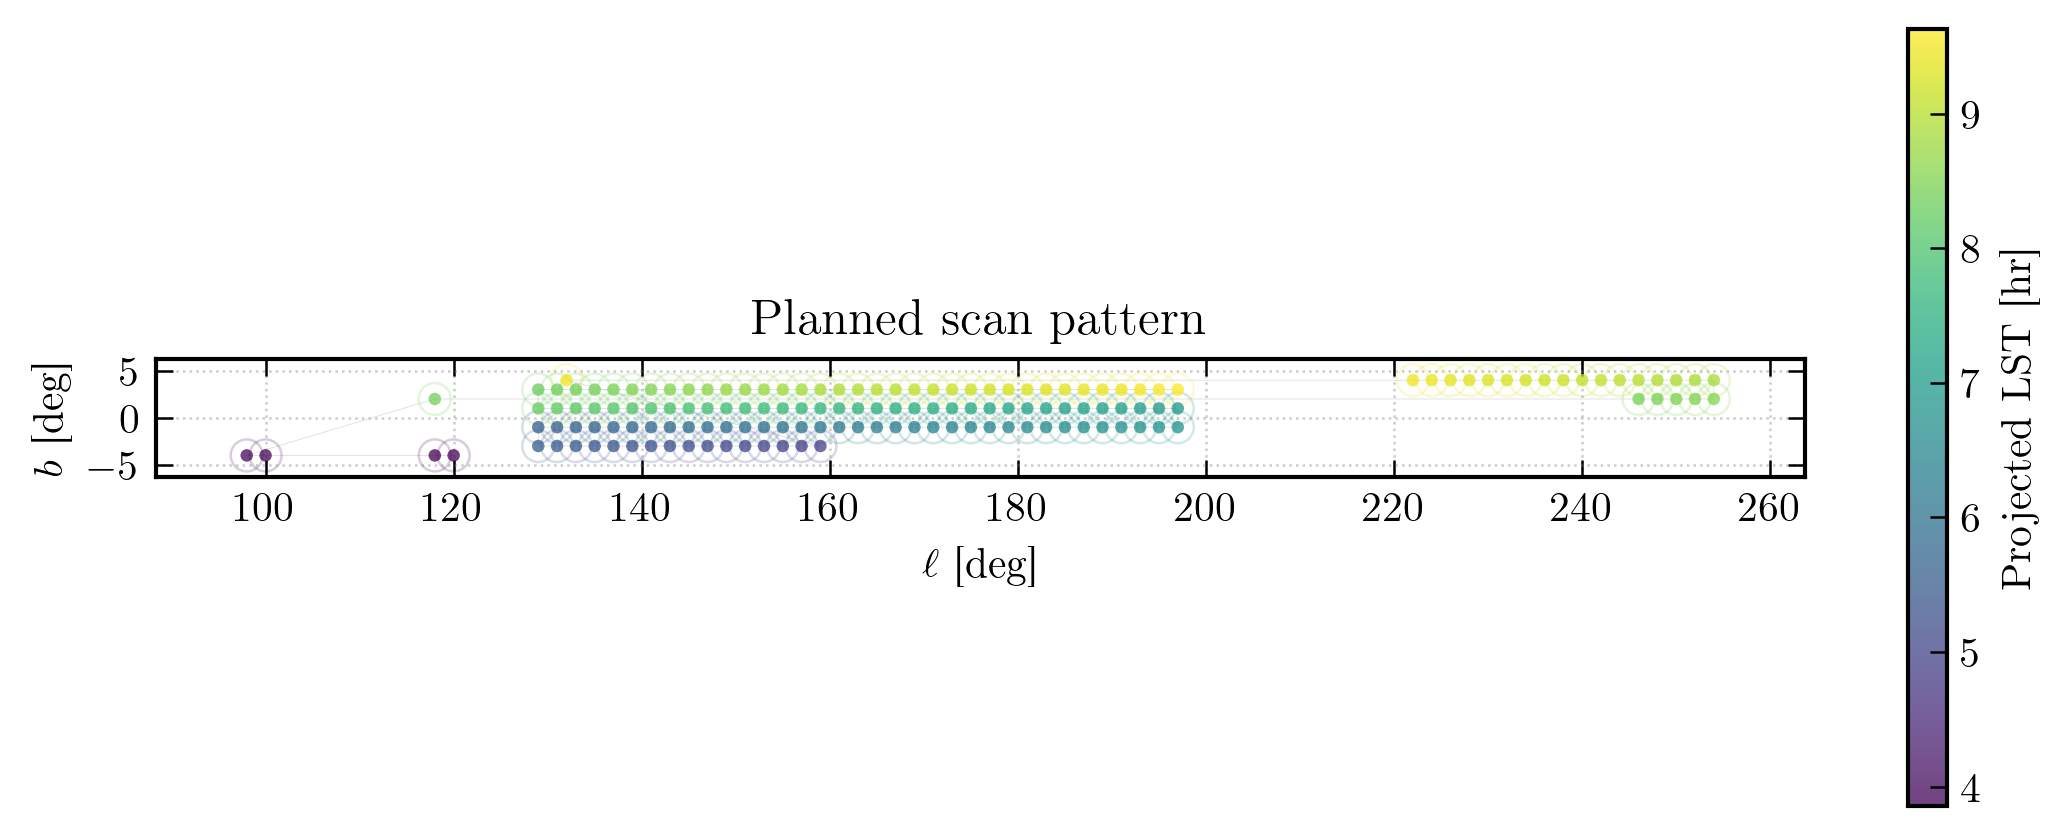

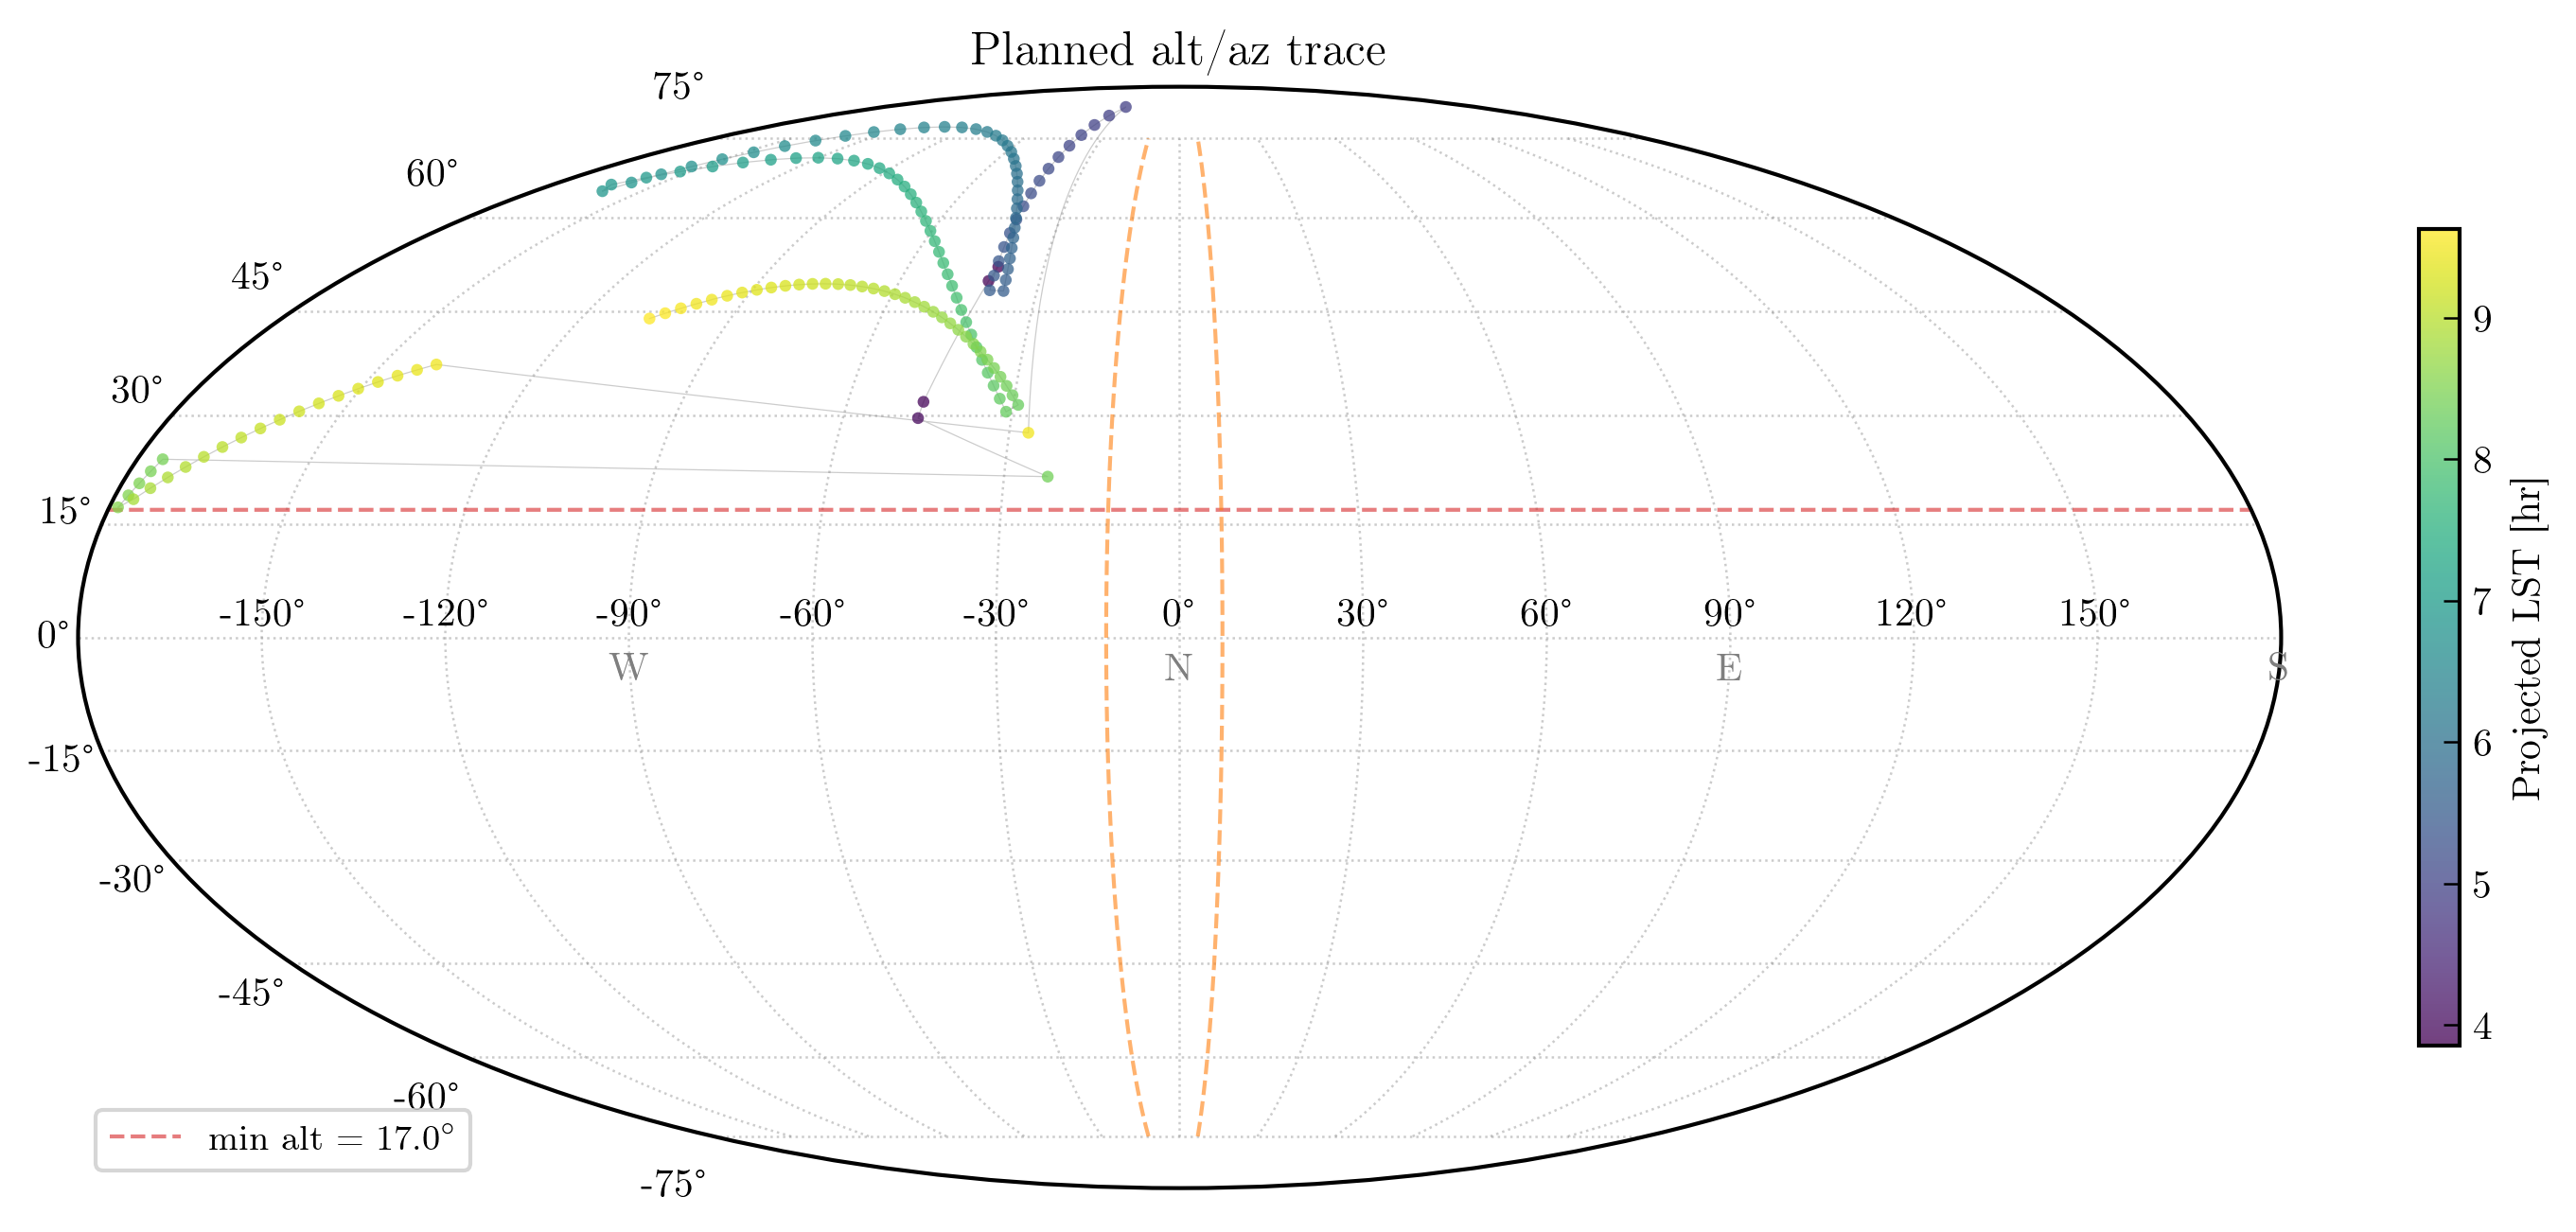

Projected LST range: 3.9-9.6 hr


In [5]:
# Compute projected LST for each simulated cell
lst_hrs_sim = np.array([
    s['time'].sidereal_time('apparent', longitude=LEO_LON * u.deg).hour
    for s in sim
])
vmin_lst, vmax_lst = lst_hrs_sim.min(), lst_hrs_sim.max()

# --- Galactic scan pattern colored by projected LST ---
from matplotlib.patches import Circle as _Circle

fig, ax = plt.subplots(figsize=(plotting.TEXTWIDTH_IN, 4))
norm = plt.Normalize(vmin=vmin_lst, vmax=vmax_lst)
cmap = plt.cm.viridis

for i, s in enumerate(sim):
    c = cmap(norm(lst_hrs_sim[i]))
    beam = _Circle((s['l'], s['b']), HPBW_DEG / 2,
                   fill=False, edgecolor=c,
                   alpha=plotting.ALPHA_EXTRA_LIGHT, lw=plotting.LW_FINE)
    ax.add_patch(beam)

sc = ax.scatter([s['l'] for s in sim], [s['b'] for s in sim],
                c=lst_hrs_sim, cmap='viridis', s=plotting.SS_FINE,
                edgecolors='none', alpha=plotting.ALPHA_STANDARD, zorder=5,
                vmin=vmin_lst, vmax=vmax_lst)
ax.plot([s['l'] for s in sim], [s['b'] for s in sim],
        lw=plotting.LW_FINE * 0.3, color='k', alpha=0.15, zorder=0)
ax.set_xlabel(r'$\ell$ [deg]', fontsize=plotting.LABEL_SIZE)
ax.set_ylabel(r'$b$ [deg]', fontsize=plotting.LABEL_SIZE)
ax.set_title('Planned scan pattern', fontsize=plotting.EMPHASIS_SIZE)
ax.set_aspect('equal')
ax.grid(True, **plotting.GRID_STYLE)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Projected LST [hr]')
fig.tight_layout()
plt.show()

# --- Alt/Az Mollweide colored by projected LST ---
az_arr = np.array([s['az'] for s in sim])
alt_arr = np.array([s['alt'] for s in sim])
az_moll = np.where(az_arr > 180, az_arr - 360, az_arr)

fig, _ax = plotting.landscapewidth_figure(5)
_ax.remove()
ax = fig.add_subplot(111, projection='mollweide')
ax.grid(True, **{k: v for k, v in plotting.GRID_STYLE.items() if k != 'color'},
        color=plotting.NEUTRAL_COLOR)

az_line = np.linspace(-np.pi, np.pi, 500)
ax.plot(az_line, np.full_like(az_line, np.deg2rad(MIN_ALT_DEG)),
        lw=plotting.LW_LIGHT, ls='--', color='C3', alpha=plotting.ALPHA_LIGHT,
        label=rf'min alt = {MIN_ALT_DEG}$^\circ$')
for az_lim in [AZ_MIN, AZ_MAX]:
    az_l = az_lim if az_lim <= 180 else az_lim - 360
    ax.axvline(np.deg2rad(az_l), lw=plotting.LW_LIGHT, ls='--',
               color='C1', alpha=plotting.ALPHA_LIGHT)

ax.plot(np.deg2rad(az_moll), np.deg2rad(alt_arr),
        lw=plotting.LW_FINE * 0.5, color='k', alpha=0.2, zorder=0)
sc = ax.scatter(np.deg2rad(az_moll), np.deg2rad(alt_arr),
                c=lst_hrs_sim, cmap='viridis', s=plotting.SS_FINE,
                edgecolors='none', alpha=plotting.ALPHA_STANDARD, zorder=5,
                vmin=vmin_lst, vmax=vmax_lst)

for azd, name in [(0, 'N'), (90, 'E'), (180, 'S'), (-90, 'W')]:
    ax.annotate(name, (np.deg2rad(azd), np.deg2rad(-2)),
                fontsize=plotting.TICK_SIZE, ha='center', va='top',
                fontweight='bold', color=plotting.NEUTRAL_COLOR)

ax.set_title('Planned alt/az trace', fontsize=plotting.EMPHASIS_SIZE)
cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label('Projected LST [hr]')
ax.legend(fontsize=plotting.LEGEND_SIZE, loc='lower left')
fig.tight_layout()
plt.show()

print(f'Projected LST range: {vmin_lst:.1f}-{vmax_lst:.1f} hr')

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


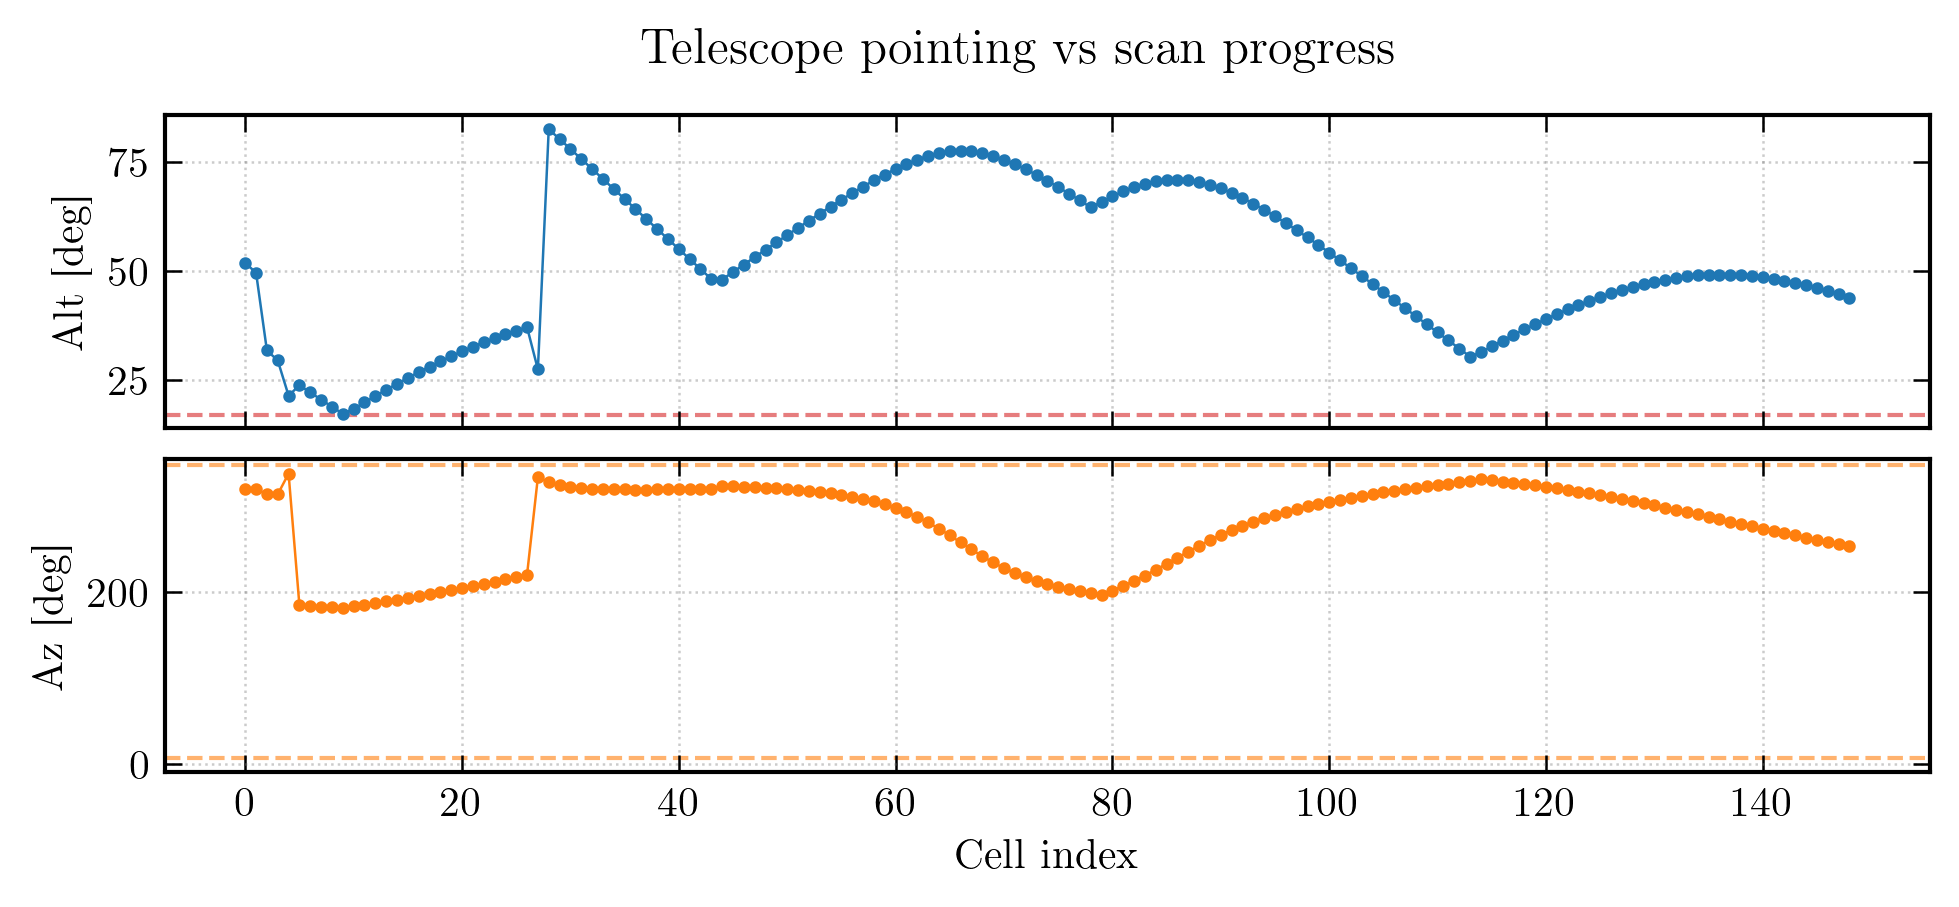

In [6]:
fig, (ax1, ax2) = plot_timeline(sim, min_alt=MIN_ALT_DEG, az_min=AZ_MIN, az_max=AZ_MAX,
                                title="Telescope pointing vs scan progress")
plt.show()